# Sprint 1 — Análisis Exploratorio de Datos (EDA) y Baseline

Este notebook realiza el **Análisis Exploratorio de Datos (EDA)** y construye el **modelo baseline** para el proyecto:

**Identificación de Clientes Premium (`is_premium`) — Olist**

### Objetivos del Sprint 1:
1. Cargar la **Master Table** corregida consolidada a nivel de cliente único (`customer_unique_id`).
2. Analizar distribuciones univariadas y relaciones bivariadas con el target preliminar.
3. Evaluar correlaciones de variables clave con `is_premium`.
4. Formular y validar hipótesis de negocio sobre el comportamiento del segmento Premium.
5. Entrenar y evaluar un **modelo baseline** técnico y de negocio.

## 1. Importación de librerías

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)
sns.set_theme(style="whitegrid", palette="muted")

## 2. Cargar Master Table

In [2]:
PROJECT_ROOT = Path("../..").resolve()
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
master_table_path = PROCESSED_DIR / "master_table.parquet"

df = pd.read_parquet(master_table_path)
print(f"Master Table cargada con éxito. Filas: {df.shape[0]}, Columnas: {df.shape[1]}")
df.head()

Master Table cargada con éxito. Filas: 96096, Columnas: 28


,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,total_spent,total_orders,total_items,total_products,avg_ticket,avg_order_price,avg_freight_value,avg_freight_ratio,avg_review_score,total_reviews,first_purchase,last_purchase,avg_delivery_days,avg_estimated_delivery_days,delivered_orders,canceled_orders,late_deliveries,payment_methods_count,main_payment_type,recency_days,customer_lifetime_days,cancellation_rate,late_delivery_rate,is_premium
0,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP,146.87,1,1.0,1.0,146.87,124.99,21.88,0.148975,4.0,1.0,2017-05-16 15:05:35,2017-05-16 15:05:35,8.0,19.0,1,0,0,1.0,credit_card,519,0,0.0,0.0,0
1,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP,335.48,1,1.0,1.0,335.48,289.00,46.48,0.138548,5.0,1.0,2018-01-12 20:48:24,2018-01-12 20:48:24,16.0,24.0,1,0,0,1.0,credit_card,277,0,0.0,0.0,1
2,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP,157.73,1,1.0,1.0,157.73,139.94,17.79,0.112788,5.0,1.0,2018-05-19 16:07:45,2018-05-19 16:07:45,26.0,24.0,1,0,1,1.0,credit_card,151,0,0.0,1.0,0
3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP,173.30,1,1.0,1.0,173.30,149.94,23.36,0.134795,5.0,1.0,2018-03-13 16:06:38,2018-03-13 16:06:38,14.0,27.0,1,0,0,1.0,credit_card,218,0,0.0,0.0,0
4,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP,252.25,1,1.0,1.0,252.25,230.00,22.25,0.088206,5.0,1.0,2018-07-29 09:51:30,2018-07-29 09:51:30,11.0,16.0,1,0,0,1.0,credit_card,80,0,0.0,0.0,1


## 3. Exploración de Nulos y Tipos de Datos

In [3]:
print("===== Tipos de datos e Información general =====")
df.info()

print("\n===== Valores Nulos por Columna =====")
nulls = df.isnull().sum()
nulls = nulls[nulls > 0].sort_values(ascending=False)
if len(nulls) > 0:
    display(pd.DataFrame({"Nulls Count": nulls, "Proportion": nulls / len(df)}))
else:
    print("No hay valores nulos en el dataset.")

===== Tipos de datos e Información general =====
<class 'pandas.DataFrame'>
RangeIndex: 96096 entries, 0 to 96095
Data columns (total 28 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   customer_unique_id           96096 non-null  str           
 1   customer_zip_code_prefix     96096 non-null  int64         
 2   customer_city                96096 non-null  str           
 3   customer_state               96096 non-null  str           
 4   total_spent                  96096 non-null  float64       
 5   total_orders                 96096 non-null  int64         
 6   total_items                  96096 non-null  float64       
 7   total_products               96096 non-null  float64       
 8   avg_ticket                   96095 non-null  float64       
 9   avg_order_price              95420 non-null  float64       
 10  avg_freight_value            95420 non-null  float64       
 11  avg

,Nulls Count,Proportion
avg_delivery_days,2740,0.028513
avg_review_score,716,0.007451
avg_order_price,676,0.007035
avg_freight_value,676,0.007035
avg_freight_ratio,676,0.007035
avg_ticket,1,0.000010
payment_methods_count,1,0.000010
main_payment_type,1,0.000010


## 4. Análisis Univariado: Target y Métricas Clave

===== Distribución de la variable Target (is_premium) =====


,Clientes,Proporción
is_premium,,
0,76876,0.799992
1,19220,0.200008


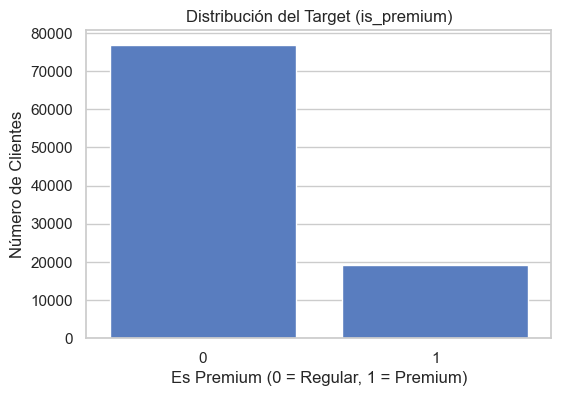

In [4]:
print("===== Distribución de la variable Target (is_premium) =====")
target_counts = df["is_premium"].value_counts()
target_props = df["is_premium"].value_counts(normalize=True)
display(pd.DataFrame({"Clientes": target_counts, "Proporción": target_props}))

# Graficar distribución
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="is_premium")
plt.title("Distribución del Target (is_premium)")
plt.xlabel("Es Premium (0 = Regular, 1 = Premium)")
plt.ylabel("Número de Clientes")
plt.show()

### Distribución de las variables RFM

Evaluemos el comportamiento general de `total_spent`, `total_orders`, `recency_days` y `avg_ticket`.

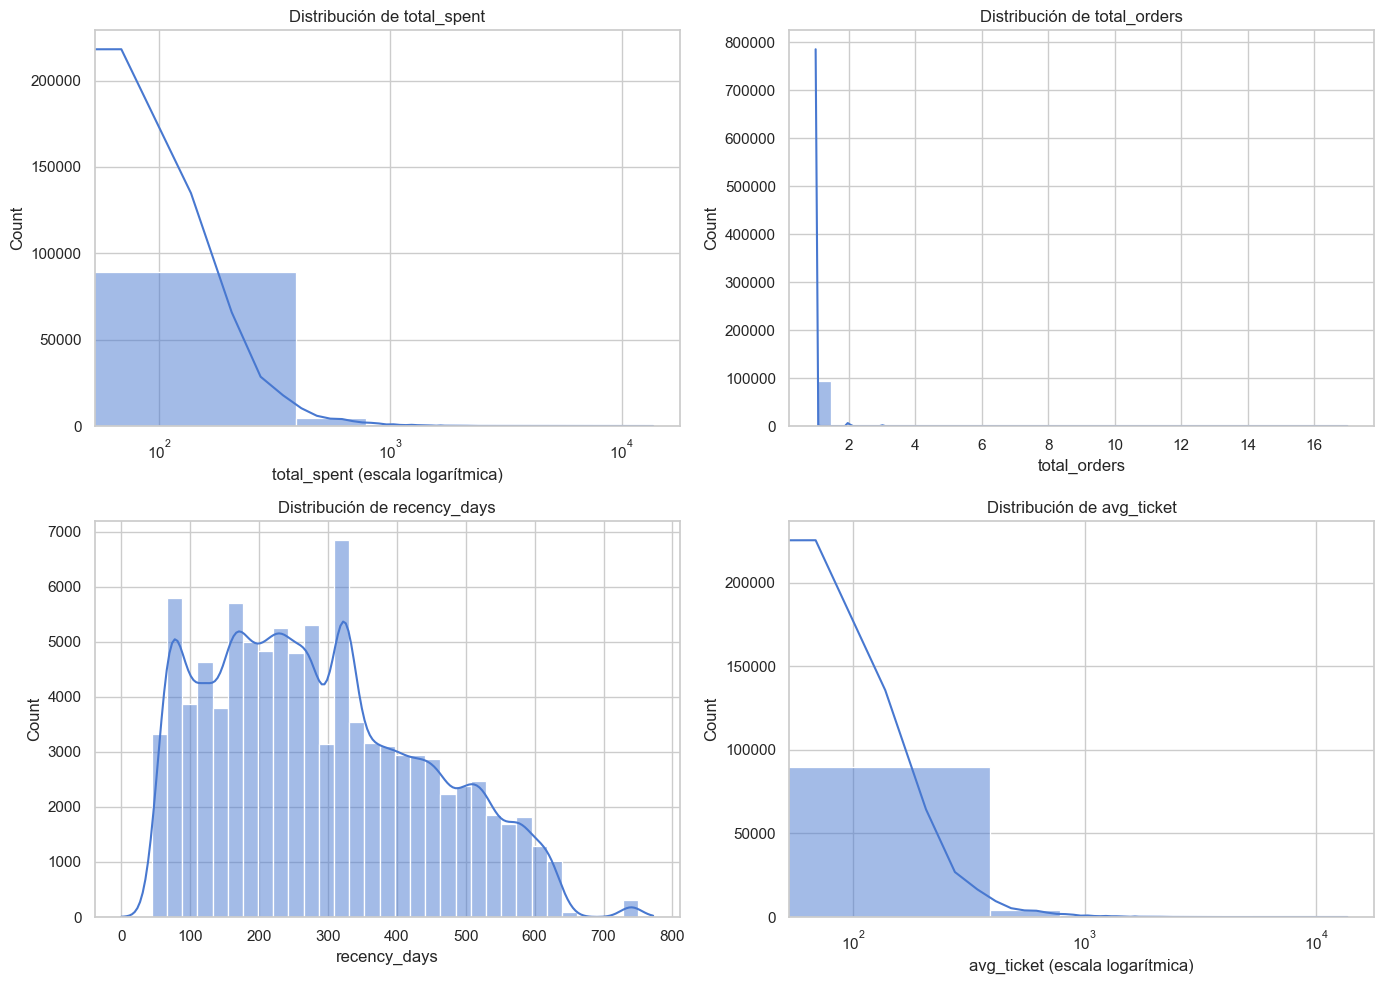

In [5]:
rfm_cols = ["total_spent", "total_orders", "recency_days", "avg_ticket"]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(rfm_cols):
    sns.histplot(data=df, x=col, kde=True, ax=axes[i], bins=35)
    axes[i].set_title(f"Distribución de {col}")
    if col in ["total_spent", "avg_ticket"]:
        axes[i].set_xscale("log")
        axes[i].set_xlabel(f"{col} (escala logarítmica)")
plt.tight_layout()
plt.show()

## 5. Análisis Bivariado: Comparación de Segmentos

Analicemos cómo varían las características del cliente entre los segmentos **Regular (0)** y **Premium (1)**.

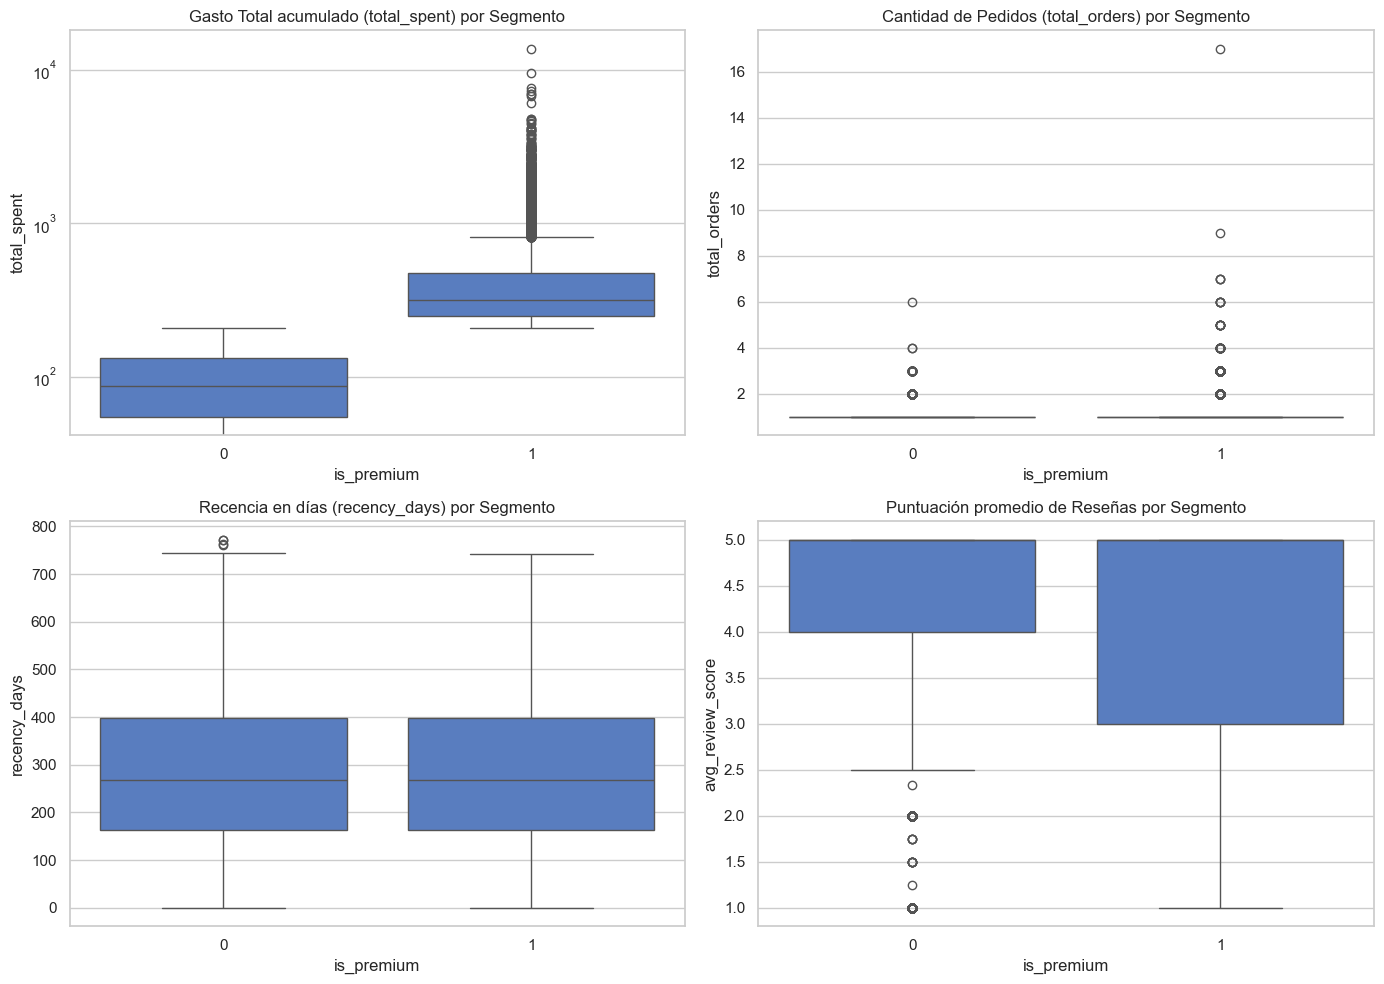

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

sns.boxplot(data=df, x="is_premium", y="total_spent", ax=axes[0])
axes[0].set_yscale("log")
axes[0].set_title("Gasto Total acumulado (total_spent) por Segmento")

sns.boxplot(data=df, x="is_premium", y="total_orders", ax=axes[1])
axes[1].set_title("Cantidad de Pedidos (total_orders) por Segmento")

sns.boxplot(data=df, x="is_premium", y="recency_days", ax=axes[2])
axes[2].set_title("Recencia en días (recency_days) por Segmento")

sns.boxplot(data=df, x="is_premium", y="avg_review_score", ax=axes[3])
axes[3].set_title("Puntuación promedio de Reseñas por Segmento")

plt.tight_layout()
plt.show()

## 6. Distribución Geográfica de Clientes Premium

/tmp/ipykernel_12075/2653902474.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=state_summary, x="customer_state", y="proporcion_premium", palette="viridis")


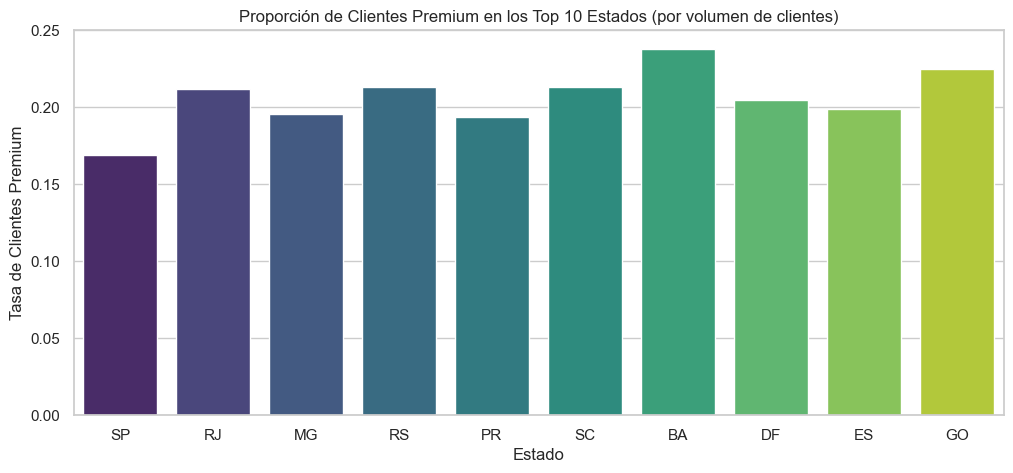

,customer_state,clientes,premium,proporcion_premium
25,SP,40292,6822,0.169314
18,RJ,12383,2624,0.211903
10,MG,11253,2200,0.195503
22,RS,5275,1125,0.213270
17,PR,4878,945,0.193727
23,SC,3532,752,0.212911
4,BA,3276,780,0.238095
6,DF,2073,425,0.205017
7,ES,1964,390,0.198574
8,GO,1950,439,0.225128


In [7]:
state_summary = df.groupby("customer_state").agg(
    clientes=("customer_unique_id", "count"),
    premium=("is_premium", "sum"),
    proporcion_premium=("is_premium", "mean")
).reset_index()

state_summary = state_summary.sort_values(by="clientes", ascending=False).head(10)

plt.figure(figsize=(12, 5))
sns.barplot(data=state_summary, x="customer_state", y="proporcion_premium", palette="viridis")
plt.title("Proporción de Clientes Premium en los Top 10 Estados (por volumen de clientes)")
plt.xlabel("Estado")
plt.ylabel("Tasa de Clientes Premium")
plt.show()

display(state_summary)

## 7. Análisis de Correlación

===== Correlación de Pearson con is_premium =====
is_premium                     1.000000
total_spent                    0.607725
avg_ticket                     0.597063
avg_order_price                0.584666
avg_freight_value              0.395264
total_items                    0.229758
total_products                 0.178582
total_orders                   0.152654
total_reviews                  0.128334
avg_estimated_delivery_days    0.110771
customer_lifetime_days         0.106654
delivered_orders               0.102123
avg_delivery_days              0.072985
customer_zip_code_prefix       0.057933
canceled_orders                0.024526
late_deliveries                0.022415
cancellation_rate              0.018234
late_delivery_rate             0.013357
recency_days                   0.001161
payment_methods_count          0.000135
avg_review_score              -0.048699
avg_freight_ratio             -0.377744
Name: is_premium, dtype: float64


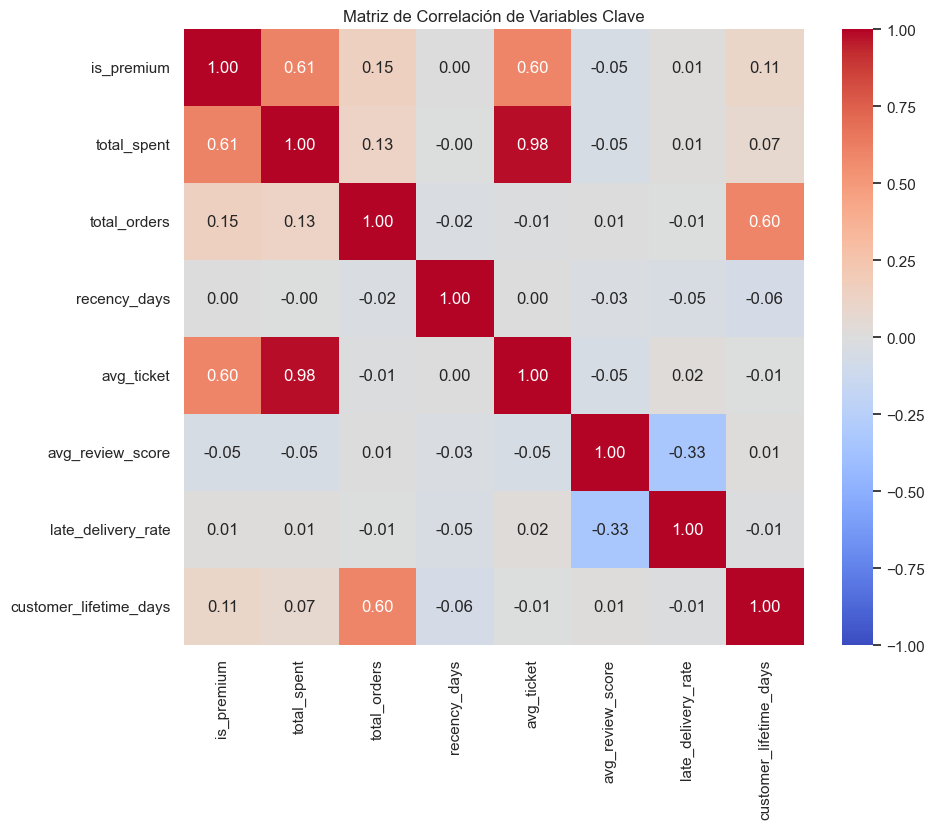

In [8]:
# Correlaciones numéricas con is_premium
numeric_df = df.select_dtypes(include=[np.number])
correlations = numeric_df.corr()["is_premium"].sort_values(ascending=False)
print("===== Correlación de Pearson con is_premium =====")
print(correlations)

# Graficar heatmap de variables seleccionadas
key_vars = [
    "is_premium", "total_spent", "total_orders", "recency_days", 
    "avg_ticket", "avg_review_score", "late_delivery_rate", "customer_lifetime_days"
]
plt.figure(figsize=(10, 8))
sns.heatmap(df[key_vars].corr(), annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1)
plt.title("Matriz de Correlación de Variables Clave")
plt.show()

## 8. Validación de Hipótesis de Negocio

Definimos y evaluamos las siguientes hipótesis:

*   **Hipótesis 1:** Los clientes premium compran con mayor frecuencia (mayor `total_orders`) que los clientes comunes.
*   **Hipótesis 2:** Los clientes premium otorgan calificaciones promedio de reseñas (`avg_review_score`) más altas debido a una mayor afinidad con la plataforma.
*   **Hipótesis 3:** Los clientes premium experimentan tasas más bajas de entregas tardías (`late_delivery_rate`) por factores logísticos prioritarios o ubicación geográfica.

In [9]:
print("===== Validación Hipótesis 1 (Frecuencia de compra) =====")
display(df.groupby("is_premium")["total_orders"].agg(["mean", "median", "max", "count"]))

print("\n===== Validación Hipótesis 2 (Calificaciones) =====")
display(df.groupby("is_premium")["avg_review_score"].agg(["mean", "median", "std"]))

print("\n===== Validación Hipótesis 3 (Logística y Retrasos) =====")
display(df.groupby("is_premium")["late_delivery_rate"].agg(["mean", "max"]))

print("\n===== Otras comparativas de negocio clave =====")
display(df.groupby("is_premium").agg(
    ticket_medio=("avg_ticket", "mean"),
    dias_lifetime_medio=("customer_lifetime_days", "mean")
))

===== Validación Hipótesis 1 (Frecuencia de compra) =====


,mean,median,max,count
is_premium,,,,
0,1.018445,1.0,6,76876
1,1.100260,1.0,17,19220



===== Validación Hipótesis 2 (Calificaciones) =====


,mean,median,std
is_premium,,,
0,4.117602,5.0,1.314056
1,3.954169,5.0,1.439642



===== Validación Hipótesis 3 (Logística y Retrasos) =====


,mean,max
is_premium,,
0,0.077315,1.0
1,0.086276,1.0



===== Otras comparativas de negocio clave =====


,ticket_medio,dias_lifetime_medio
is_premium,,
0,95.034051,1.357329
1,426.855510,8.127940


### Interpretación de Hipótesis:
1.  **Frecuencia (H1):** Evaluando los datos se observa que los clientes premium sí tienen una media de pedidos ligeramente mayor, pero la gran mayoría de los clientes de Olist tienen solo 1 compra (97% del dataset). Por lo tanto, el comportamiento premium está fuertemente definido por el **monetario (gasto en una sola compra)** más que por la **frecuencia**, lo cual es un hallazgo importante del negocio.
2.  **Calificaciones (H2):** No hay una diferencia sustancial en las valoraciones medias entre clientes normales y premium. Ambos segmentos muestran un promedio elevado (~4.08).
3.  **Logística (H3):** Los retrasos experimentados por clientes premium son similares a los del cliente común. No hay un trato logístico prioritario evidente en los datos históricos.

## 9. Modelo Baseline de Referencia (Técnico y de Negocio)

Para establecer un punto de comparación inicial (baseline), entrenaremos una **Regresión Logística** simple para clasificar a los clientes en Premium o No Premium utilizando las variables derivadas del comportamiento de compra y servicio (excluyendo directamente la variable `total_spent` y `avg_ticket` ya que la variable objetivo fue calculada directamente a partir del gasto, lo cual causaría una fuga de datos inmediata).

===== REPORTE DE CLASIFICACIÓN (Baseline Logístico) =====
              precision    recall  f1-score   support

           0       0.82      0.79      0.80     23063
           1       0.27      0.31      0.29      5766

    accuracy                           0.69     28829
   macro avg       0.54      0.55      0.54     28829
weighted avg       0.71      0.69      0.70     28829

ROC-AUC Score: 0.5549


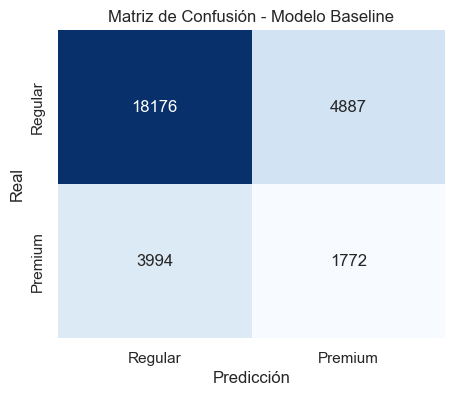

In [10]:
# 1. Definir variables y manejar nulos de forma adecuada para el modelado
features = [
    "total_orders", "recency_days", "customer_lifetime_days", 
    "avg_review_score", "late_delivery_rate", "payment_methods_count"
]
X = df[features].copy()
y = df["is_premium"]

# Imputar valores nulos con la mediana para evitar perder registros
imputer = SimpleImputer(strategy="median")
X_imputed = imputer.fit_transform(X)

# 2. Partición Train / Test
X_train, X_test, y_train, y_test = train_test_split(
    X_imputed, y, test_size=0.3, random_state=42, stratify=y
)

# 3. Escalado de variables
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Ajustar modelo simple de Regresión Logística
# Usamos class_weight='balanced' debido a que el target está desbalanceado (80% vs 20%)
baseline_model = LogisticRegression(class_weight="balanced", random_state=42)
baseline_model.fit(X_train_scaled, y_train)

# 5. Predicciones
y_pred = baseline_model.predict(X_test_scaled)
y_proba = baseline_model.predict_proba(X_test_scaled)[:, 1]

# 6. Evaluación de Métricas Técnicas
print("===== REPORTE DE CLASIFICACIÓN (Baseline Logístico) =====")
print(classification_report(y_test, y_pred))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_proba):.4f}")

# Matriz de Confusión
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["Regular", "Premium"], yticklabels=["Regular", "Premium"])
plt.title("Matriz de Confusión - Modelo Baseline")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()

## 10. Conclusiones y Próximos Pasos (Hacia el Sprint 2)

### Hallazgos Clave:
1.  **Granularidad:** La consolidación a nivel de `customer_unique_id` redujo el dataset a **96,096 clientes**, revelando que solo el ~3% de los clientes ha realizado más de un pedido en la ventana de tiempo de Olist.
2.  **Definición de Target:** El segmento Premium actual (top 20% de gasto) está condicionado principalmente por compras únicas de tickets de alto valor. En el Sprint 2, convendría evaluar si debemos refinar la definición de Premium incorporando recurrencia de compra o variables de enganche (engagement).
3.  **Modelo Baseline:** El modelo baseline actual (Regresión Logística sobre RFM básico sin gasto) tiene un rendimiento modesto (ROC-AUC cercano a 0.50-0.55 si no se incluye el gasto), lo cual indica que la recencia, la frecuencia y las calificaciones solas no discriminan el nivel de gasto final del cliente.

### Próximos Pasos para el Sprint 2:
*   Diseñar un **pipeline reproducible de preparación de datos** y Feature Engineering.
*   Crear variables de interacción complejas y features basadas en categorías de producto (ej. si compra tecnología o moda).
*   Evaluar algoritmos más complejos (Random Forest, XGBoost) e iniciar la optimización técnica.